# Machine Learning in Science - 2025-2026
- Teacher: Alessandro Corbetta [a.corbetta@tue.nl](mailto:a.corbetta@tue.nl)
- Co-teacher: Chiel van der Laan [c.v.d.laan@tue.nl](mailto:c.v.d.laan@tue.nl)

## [02-03-2026] - Ungraded Assignment: Classifying written digits (MNIST)

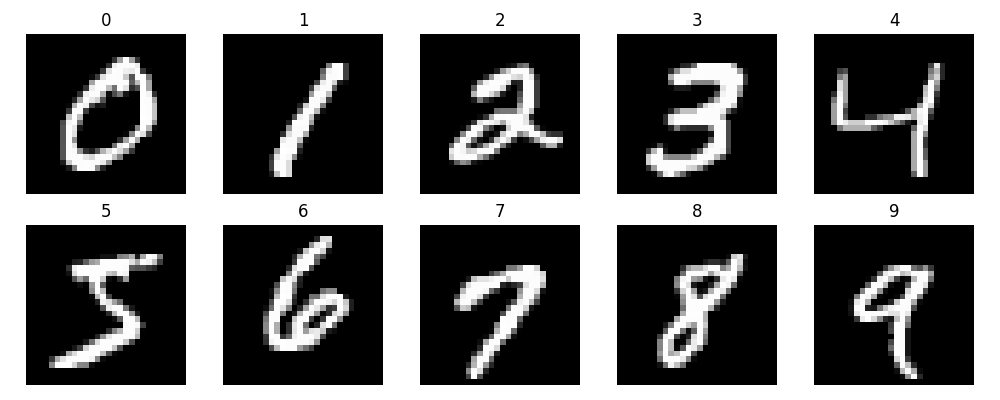

Define and train a neural network that learns to classify written digits. We will be using the MNIST dataset. MNIST is a large dataset that contains 28x28 pixel images of written digits between 0 and 9 that are each annotated with a label indicating the digit represented by the image. Therefore, this is an excellent dataset to use for supervised learning, classification tasks.

We will look at two classification problems.
 - The first problem is a binary classification problem where you build a network that tries to predict whether the given digit is either a 1 or a 7.
 - The second problem is a multiclass classification problem that extends the previous problem to include all 10 digits.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import manual_seed, nn, no_grad, optim
from torch.utils.data import DataLoader, Dataset
device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.set_default_device(device)

In [2]:
torch.manual_seed(1032025); # set the random seed for reproducibility, dont do this in your own code.

## Import the data

The data is provided as four `.pt` files that each contain a single PyTorch tensor.

In [3]:
class TensorData(Dataset):
    def __init__(self, input_tensor, label_tensor):
        self.input = input_tensor
        self.labels = label_tensor

    def __len__(self):
        return self.input.size()[0]

    def __getitem__(self, index):
        return self.input[index], self.labels[index]

In [4]:
train_input = torch.load("./mnist_train_input.pt").to(device)
train_labels = torch.load("./mnist_train_labels.pt").to(device)

test_input = torch.load("./mnist_test_input.pt").to(device)
test_labels = torch.load("./mnist_test_labels.pt").to(device)

print(f"{train_input.shape=}")
print(f"{train_labels.shape=}")
print(f"{test_input.shape=}")
print(f"{test_labels.shape=}")

train_input.shape=torch.Size([60000, 28, 28])
train_labels.shape=torch.Size([60000])
test_input.shape=torch.Size([10000, 28, 28])
test_labels.shape=torch.Size([10000])


The inputs are 2D grayscale images of size 28x28 where every pixel is represented by an 8-bit integer with a value between 0 and 255. However, the PyTorch model expects floating point values. Therefore, we normalize the data and convert to float by dividing each pixel value by `255.0`.

In [5]:
train_input = train_input / 255.0
test_input = test_input / 255.0

In [6]:
def plot_sample(image, label):
    # We need to remove the batch dimension to get a 2D tensor that we can plot.
    # this makes the image 28x28 instead if it is 1x28x28.
    # if you already input something that is 28x28, the reshape will not change it.
    plt.imshow(image.reshape(28, 28).detach().cpu(), cmap='grey')
    plt.title(f"Label: {label}")
    plt.show()

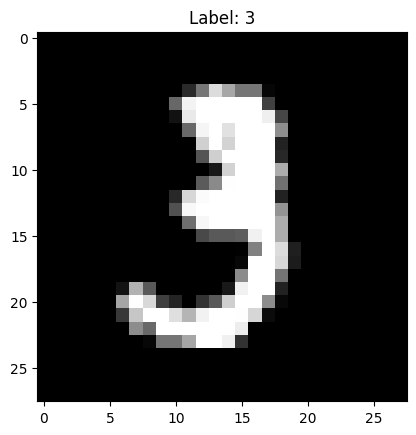

In [7]:
image = train_input[10]
label = train_labels[10]

plot_sample(image, label)

## 1. Binary classification

Let's start by reducing the problem to a binary classification problem. For example, we can train a neural network that learns to distinguish between a 1 and a 7. Quite a feat! In order to do so we first need to reduce our train and test datasets.

In [8]:
def make_binary_subset(inputs, labels):
    # First we collect the indices of all the samples that represent a 1 or a 7.
    train_indices_1_or_7 = [
        index for index, label in enumerate(labels) if label == 1 or label == 7
    ]
    # Above is a list comprehension: 
    # This is a concise way to loop through an something (in this case, the labels) 
    # and construct a new list based on some condition (in this case, whether the label is 1 or 7).
    # it is equivalent to the following code:
    # train_indices_1_or_7 = []
    # for index, label in enumerate(labels):
    #     if label == 1 or label == 7:
    #         train_indices_1_or_7.append(index)

    # Then we return a subset of the given dataset that only contains these samples.
    return inputs[train_indices_1_or_7], labels[train_indices_1_or_7]

In [9]:
train_input_binary, train_labels_binary = make_binary_subset(train_input, train_labels)
test_input_binary, test_labels_binary = make_binary_subset(test_input, test_labels)

In [10]:
print(f"First few entries before filtering: {train_labels[:10]}")
print(f"First few entries after filtering: {train_labels_binary[:10]}")

First few entries before filtering: tensor([5, 0, 4, 1, 9, 2, 1, 3, 1, 4], device='cuda:0')
First few entries after filtering: tensor([1, 1, 1, 1, 7, 1, 1, 7, 7, 1], device='cuda:0')


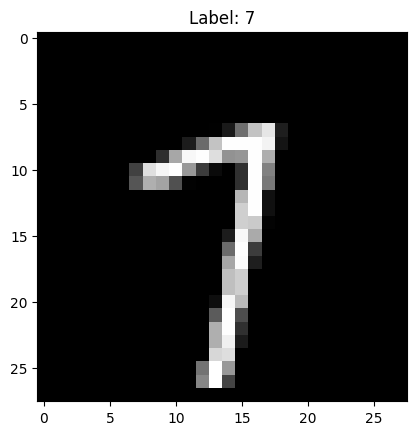

In [11]:
image = train_input_binary[10]
label = train_labels_binary[10]

plot_sample(image, label)

In [12]:
one_count = sum((1 for label in train_labels_binary if label == 1))
seven_count = sum((1 for label in train_labels_binary if label == 7))

print(
    f"The binary classification dataset has {one_count} ones, and {seven_count} sevens."
)

The binary classification dataset has 6742 ones, and 6265 sevens.


### Label encoding

The next step involves the encoding of our labels to effectively train a neural network. In this case we only have two classes so we can choose to output a single probability. For example, the probability that the output is a 7. With this logic we can encode our labels. Labels indicating a 1 are encoded as $0.0$, and labels indicating a 7 are encoded as $1.0$. The model will learn to predict this probability. The output is discretized as follows. A predicted probability $<0.5$ indicates that the model predicts a 1, and a probability $\geq 0.5$ indicates that the model predicts a 7.

Remember that PyTorch expects the label tensors to be of shape `(batch_size, 1)`.

In [13]:
def encode_labels_binary(labels, one_class):
    one_class_idx = [index for index, label in enumerate(labels) if label == one_class]

    encoded = torch.zeros_like(labels, dtype=torch.float32)
    encoded[one_class_idx] = 1.0

    return encoded.reshape(-1, 1)

In [14]:
train_labels_binary_encoded = encode_labels_binary(train_labels_binary, 7)
test_labels_binary_encoded = encode_labels_binary(test_labels_binary, 7)

In [15]:
print("Train labels encoding")
print(train_labels_binary[:10])
print(train_labels_binary_encoded[:10])

print("Test labels encoding")
print(test_labels_binary[:10])
print(test_labels_binary_encoded[:10])

Train labels encoding
tensor([1, 1, 1, 1, 7, 1, 1, 7, 7, 1], device='cuda:0')
tensor([[0.],
        [0.],
        [0.],
        [0.],
        [1.],
        [0.],
        [0.],
        [1.],
        [1.],
        [0.]], device='cuda:0')
Test labels encoding
tensor([7, 1, 1, 1, 7, 7, 1, 1, 7, 7], device='cuda:0')
tensor([[1.],
        [0.],
        [0.],
        [0.],
        [1.],
        [1.],
        [0.],
        [0.],
        [1.],
        [1.]], device='cuda:0')


Remember in PyTorch, input data is typically expected to have the shape:

`(batch_size, num_features)`

However, our current dataset has the shape:

`(batch_size, 28, 28)`

Each sample is a 28 × 28 image. Instead of treating it as a 2D grid, we need to convert each image into a single flattened vector.

The total number of features per image is:

`28 × 28 = 784`

Therefore, we need to reshape the data from:

`(batch_size, 28, 28)`

to:

`(batch_size, 784)`

It is important that this reshaping is done in a consistent and reversible way, so that we can reconstruct the original image shape later if needed.

The reshape method is prefect for this.

In [16]:
# Create the train dataset

data_train_binary = TensorData(
    train_input_binary.reshape(-1, 28 * 28), train_labels_binary_encoded
)

In [17]:
# for clarity the reshape is doing the following:
print(train_input_binary.shape) # (13007, 28, 28)
p = train_input_binary.reshape(-1, 28 * 28)
print(p.shape) # (13007, 784)

torch.Size([13007, 28, 28])
torch.Size([13007, 784])


### Define your model

Take these two notes into account:
 - The input of the network is the flattened image of size `28 * 28`.
 - We want the prediction to be a value between 0.0 and 1.0. What function can we use to implicitly respect this range?

In [18]:
def make_model_binary():
    return nn.Sequential(
        nn.Linear(28 * 28, 8, bias=True),
        nn.ReLU(),
        nn.Linear(8, 4, bias=True),
        nn.ReLU(),
        nn.Linear(4, 1, bias=True),
        nn.Sigmoid(),
    )

### Implement the training loop and train your model

Take note of the following:
 - Use the binary cross-entropy loss as your loss function.
 - When printing, print the train loss, test loss, and the accuracy on the test set.

In [19]:
def binary_accuracy(predictions, labels):
    # should return the accuracy as a float between 0 and 1.
    # or
    # correct = predictions.round() == labels
    # accuracy = correct.float().mean()
    return torch.sum((predictions > 0.5) == labels) / len(labels)

In [20]:
def train_model(
    train_data,
    test_input,
    test_labels,
    model,
    loss_fn,
    accuracy_fn,
    epochs=10,
    lr=0.01,
    batch_size=1,
    print_every=1,
):
    loss_dict = {"train": [], "test": [], "test_acc": []}

    # Initialize optimizer
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # We use a `DataLoader` to get batching for free!
    train_data_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, generator=torch.Generator(device=device))

    # Print header.
    print(f"Epoch    Train loss      Test loss       Test accuracy")

    for epoch in range(epochs):
        epoch_loss_sum = 0

        for x_batch, y_batch in train_data_loader:
            # Reset optimizer gradients.
            optimizer.zero_grad()

            # Predict the output
            y_pred = model(x_batch)

            # Compute the loss
            loss = loss_fn(y_pred, y_batch)
            epoch_loss_sum += loss.item()

            # Compute gradients according to newly computed loss.
            loss.backward()

            # Update the model parameters.
            optimizer.step()

        loss_dict["train"].append(epoch_loss_sum / len(train_data_loader))

        with no_grad():
            test_pred = model(test_input)
            test_loss = loss_fn(test_pred, test_labels)
            loss_dict["test"].append(test_loss.item())

            test_accuracy = accuracy_fn(test_pred, test_labels)
            loss_dict["test_acc"].append(test_accuracy.item())

        if (epoch + 1) % print_every == 0:
            print(
                f"{epoch+1: <7}  {loss_dict['train'][-1]: <14.6e}  {loss_dict['test'][-1]: <13.6e}  {loss_dict['test_acc'][-1]: .6}"
            )

    return model, loss_dict

In [21]:
model = make_model_binary()
loss_fn = nn.BCELoss()

model, loss_dict = train_model(
    data_train_binary,
    test_input_binary.reshape(-1, 28 * 28),
    test_labels_binary_encoded,
    model,
    loss_fn,
    binary_accuracy,
    epochs=100,
    lr=1e-5,
    batch_size=64,
    print_every=10,
)

Epoch    Train loss      Test loss       Test accuracy
10       6.015399e-01    5.953067e-01    0.524734
20       5.067571e-01    4.999732e-01    0.524734
30       4.280404e-01    4.219574e-01    0.899676
40       3.536001e-01    3.493833e-01    0.948682
50       2.813935e-01    2.779963e-01    0.963477
60       2.129905e-01    2.108225e-01    0.975497
70       1.544119e-01    1.532248e-01    0.981045
80       1.086311e-01    1.088313e-01    0.987055
90       7.629604e-02    7.751032e-02    0.98798
100      5.474039e-02    5.676176e-02    0.989829


In [22]:
def plot_losses(train, test, loss_label="BCE Loss"):
    plt.semilogy(train, label="train", marker=".", lw=2)
    plt.semilogy(test, label="test", marker=".", lw=2)
    plt.xlabel("Epoch")
    plt.ylabel(loss_label)
    plt.legend()
    plt.show()
    
def plot_accuracies(test_acc, expected_value_random_guess = 0.5):
    plt.plot(test_acc, label="test accuracy", marker=".", lw=2)
    plt.axhline(expected_value_random_guess, color='red', linestyle='--', label='Random Guess accuracy')
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

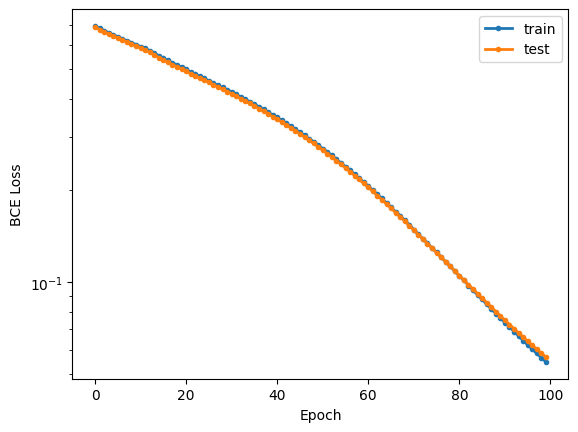

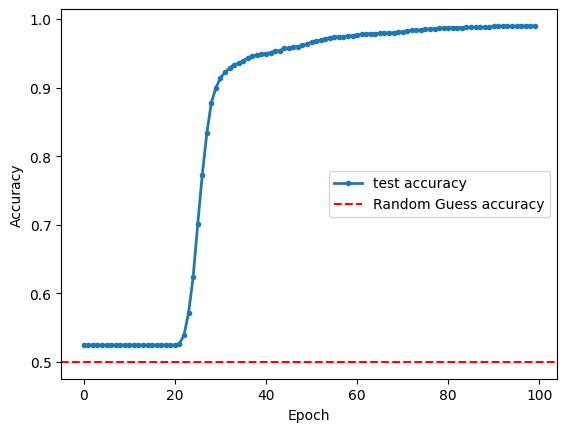

In [23]:
plot_losses(loss_dict["train"], loss_dict["test"])
plot_accuracies(loss_dict['test_acc'])

In [24]:
with torch.no_grad():
    y_pred = model(test_input_binary.reshape(-1, 28 * 28))
    print(binary_accuracy(y_pred, test_labels_binary_encoded).item())

0.989828884601593


### Visualize the worst performing samples

Find the 5 test samples for which your model performs worst and visualize them. Does it make sense that the model struggles to correctly predict the digits in these samples? 

In [25]:
def check_prediction(pred, truth, true_value=7, wrong_value=1):
    # remember 1.0 is 100% sure it's a 7
    #          0.0 is 100% sure it's a 1
    
    # convert float back to class label
    predicted_value = torch.where(pred >= 0.5, # condition
                                  torch.tensor(true_value), # value if condition is true 
                                  torch.tensor(wrong_value)) # value if condition is false
    # convert ground truth float back to class label
    actual_value = torch.where(truth >= 0.5, # condition
                               torch.tensor(true_value), # value if condition is true 
                               torch.tensor(wrong_value))# value if condition is false
    
    # if they mismatch, then the prediction is wrong
    is_prediction_wrong = (predicted_value != actual_value).item()
    
    # build a string to express the result
    str_bool = "correct" if not is_prediction_wrong else "wrong"
    str_return = f"model pred: {pred.item():.2f}, predicted value: {predicted_value.item()}, GT: {actual_value.item()}, the prediction is {str_bool}"
    return str_return
    
# example usage:
pred_0 = torch.tensor([[0.8]])  # Example prediction a 7
truth_0 = torch.tensor([[1.0]])  # Ground truth (it's actually a 7)
print(check_prediction(pred_0, truth_0))
pred_1 = torch.tensor([[0.3]])  # Example prediction a 1
truth_1 = torch.tensor([[1.0]])  # Ground truth (it's actually a 7)
print(check_prediction(pred_1, truth_1))

    

model pred: 0.80, predicted value: 7, GT: 7, the prediction is correct
model pred: 0.30, predicted value: 1, GT: 7, the prediction is wrong


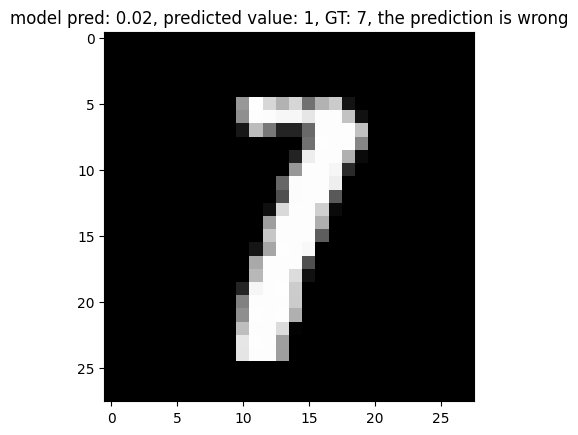

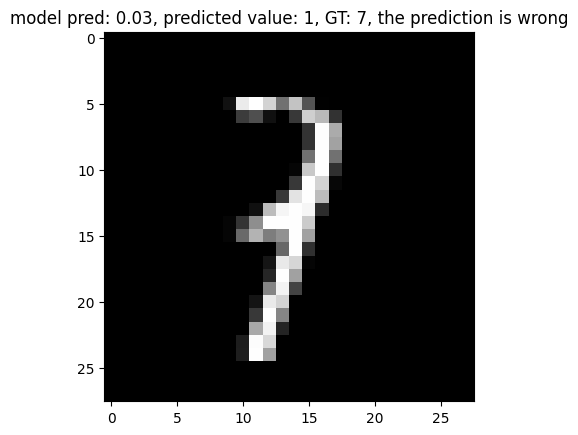

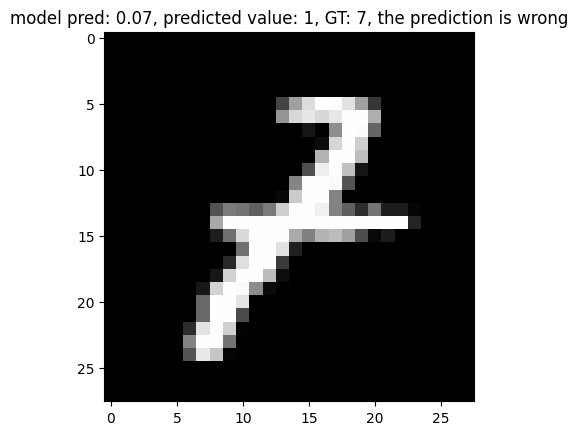

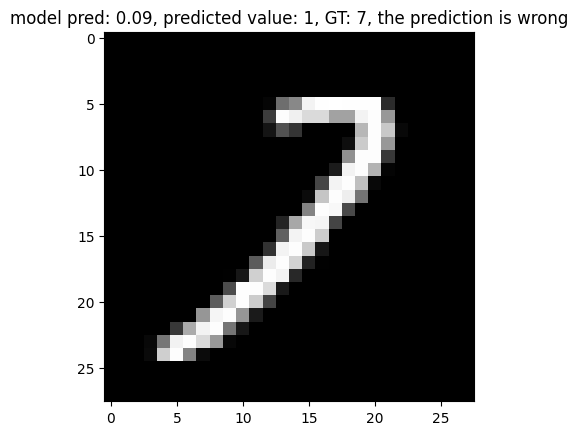

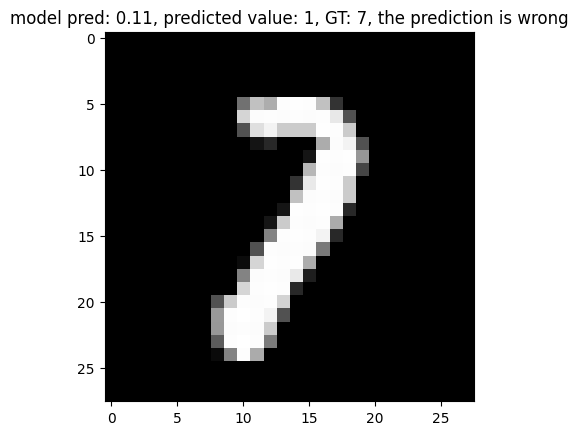

In [26]:
with torch.no_grad():
    test_sample = test_input_binary.reshape(-1, 28 * 28)
    pred = model(test_sample)
    # acc = binary_accuracy(pred, test_labels_binary_encoded)
    
acc_per = torch.abs(pred - test_labels_binary_encoded)[:,0]
N_samples = 5
worst_indices = torch.topk(
    acc_per, N_samples, largest=True
).indices

for i in worst_indices:
    plt.imshow(test_input_binary[i].detach().cpu(),cmap='grey')
    title = check_prediction(pred[i], test_labels_binary_encoded[i])
    plt.title(title)
    plt.show()
    

## 2. Multiclass classification

The next problem that you are going to tackle is multiclass classification. That is, instead of predicting whether the given written digit is a 1, or a 7, the model is now presented with digits between 0 and 9.

There are a number of things to consider when generalizing the binary classification code to be able to perform multiclass classification:
 - the label encoding needs to be updated, as we now consider more that two classes,
 - a new network needs to be built that respects the dimensions of the new encoding, and 
 - the binary cross entropy loss and binary accuracy functions need to be replaced by multiclass equivalents.

Try to reuse as much of the code used for the binary classification problem as possible.

### One-hot encoding

Instead of encoding the labels to a single probability, we need an encoding that can incorporate more than two classes. One-hot encoding is a technique that is often used in this case. 

The labels are encoded as an array of values between 0 and 1 with a length equal to the number of classes in the problem. The sum of these values should be equal to 1. Each value then indicates the relative likelihood that the given written digit is of the corresponding class. The labels can then be encoded by setting the value corresponding to the desired class to 1. For example,
 - `0 -> [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]`, and
 - `7 -> [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0]`.

The output of the network will have the same shape, its prediction is then the class with the highest relative probability (in our case we can use the `torch.argmax` function to convert the one-hot encoded prediction into the class value).

**Hint**: does PyTorch provide any functions to perform one-hot encoding?

In [27]:
def one_shot_encode_labels(labels, num_labels=10):
    amount_labels = len(labels)
    array_shape = (amount_labels, num_labels)
    
    torch_holder = torch.zeros(array_shape)
    
    for i, label in enumerate(labels):
        torch_holder[i,label] = 1.0
    return torch_holder

# This is the above function but much more effecient
train_labels_encoded = nn.functional.one_hot(train_labels, 10).float()
test_labels_encoded = nn.functional.one_hot(test_labels, 10).float()

print(train_labels.shape)
print(train_labels[:10])

print(train_labels_encoded.shape)
print(train_labels_encoded[:10])

torch.Size([60000])
tensor([5, 0, 4, 1, 9, 2, 1, 3, 1, 4], device='cuda:0')
torch.Size([60000, 10])
tensor([[0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
        [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]], device='cuda:0')


In [28]:
data_train = TensorData(train_input.reshape(-1, 28 * 28), train_labels_encoded)

### Define your model

Remember that the labels now have dimension `(batch_size, 10)`.

In [ ]:
def make_model():
    return nn.Sequential(
        nn.Linear(28 * 28, 16, bias=True),
        nn.ReLU(),
        nn.Linear(16, 16, bias=True),
        nn.ReLU(),
        nn.Linear(16, 10, bias=True)
        # no soft max needed because Torch has it inmplemnted as part of their CrossEntropyLoss function, see:
        # https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html
    )

### Train your model

Remember to update accuracy and loss function accordingly.

In [30]:
def multiclass_accuracy(prediction, label):
    return sum(torch.argmax(prediction, dim=1) == torch.argmax(label, dim=1)) / len(
        label
    )

In [31]:
model = make_model()
loss_fn = nn.CrossEntropyLoss()

model, loss_dict = train_model(
    data_train,
    test_input.reshape(-1, 28 * 28),
    test_labels_encoded,
    model,
    loss_fn,
    multiclass_accuracy,
    epochs=300,
    lr=1e-5,
    batch_size=128,
    print_every=10,
)

Epoch    Train loss      Test loss       Test accuracy
10       2.172315e+00    2.160604e+00    0.3835
20       2.005299e+00    2.000951e+00    0.5201
30       1.911501e+00    1.910403e+00    0.5546
40       1.813074e+00    1.808045e+00    0.7125
50       1.744035e+00    1.739838e+00    0.7883
60       1.711244e+00    1.708398e+00    0.7981
70       1.692028e+00    1.690206e+00    0.8051
80       1.679715e+00    1.678602e+00    0.8087
90       1.671094e+00    1.670443e+00    0.8132
100      1.664579e+00    1.664404e+00    0.8153
110      1.659479e+00    1.659668e+00    0.8174
120      1.655305e+00    1.655853e+00    0.8194
130      1.651805e+00    1.652684e+00    0.8213
140      1.648896e+00    1.650047e+00    0.8229
150      1.646369e+00    1.647698e+00    0.825
160      1.644083e+00    1.645648e+00    0.826
170      1.642080e+00    1.643841e+00    0.8267
180      1.640312e+00    1.642268e+00    0.8283
190      1.638626e+00    1.640842e+00    0.8296
200      1.637187e+00    1.639545e+

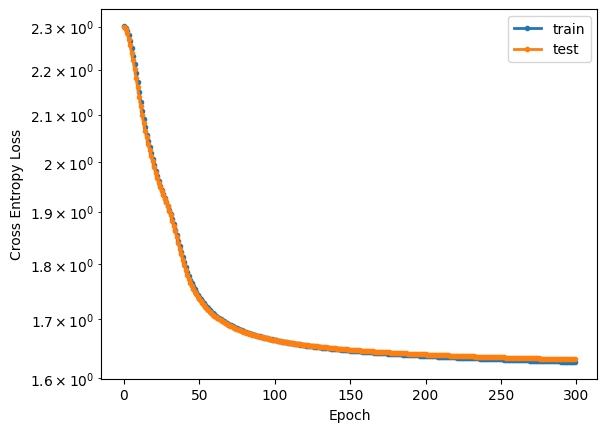

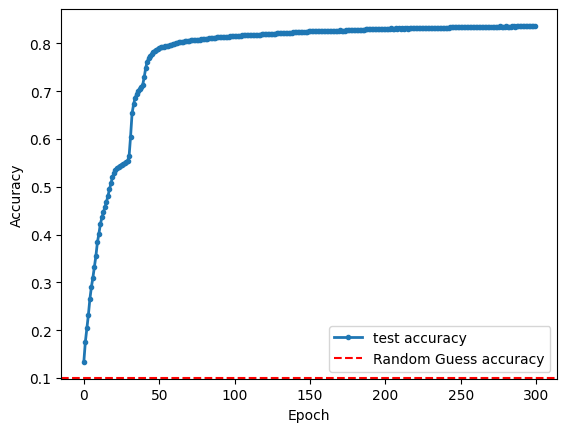

In [32]:
plot_losses(loss_dict["train"], loss_dict["test"], loss_label="Cross Entropy Loss")
plot_accuracies(loss_dict['test_acc'], expected_value_random_guess=0.1)

In [33]:
with torch.no_grad():
    y_pred = model(test_input.reshape(-1, 28 * 28))
    print(multiclass_accuracy(y_pred, test_labels_encoded).item())

0.8362999558448792


### Visualize the worst performing samples

Find the 5 test samples for which your model performs worst and visualize them. Does it make sense that the model struggles to correctly predict the digits in these samples? 

In [34]:
def how_close_is_multiclass_predict(pred, truth):
    predicted_value = torch.argmax(pred, dim=1)
    actual_value = torch.argmax(truth, dim=1)
    
    is_prediction_wrong = (predicted_value != actual_value).item()
    
    str_bool = "correct" if not is_prediction_wrong else "wrong"
    str_return = f"model pred: {predicted_value.item()}, GT: {actual_value.item()}, the prediction is {str_bool}"
    return str_return

pred_3 = torch.tensor([[0.1, 0.2, 0.3, 0.4, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]])  # Example prediction a 3
truth_3 = torch.tensor([[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]])  # Ground truth (it's actually a 3)
print(how_close_is_multiclass_predict(pred_3, truth_3))

model pred: 3, GT: 3, the prediction is correct


The sample has index: 1337.
Its label is 2, but the model predicted it to be a 6.


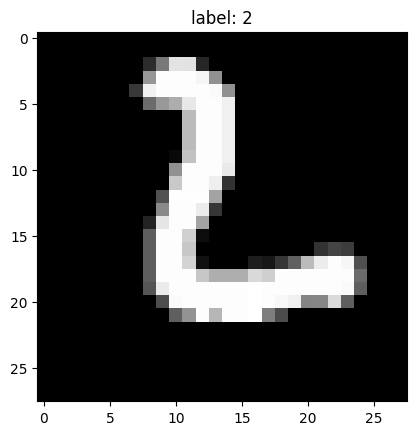

The sample has index: 1049.
Its label is 2, but the model predicted it to be a 6.


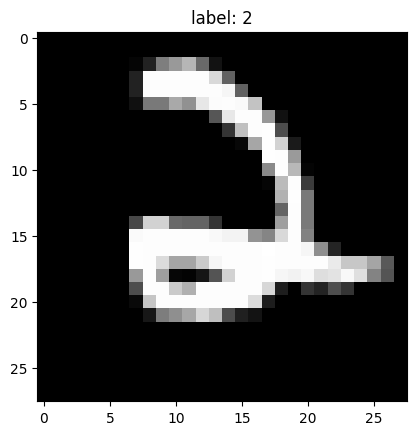

The sample has index: 1936.
Its label is 2, but the model predicted it to be a 3.


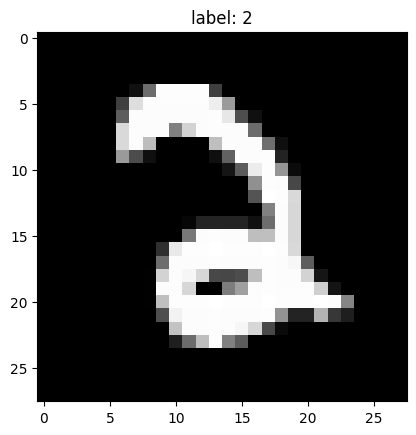

The sample has index: 2602.
Its label is 2, but the model predicted it to be a 3.


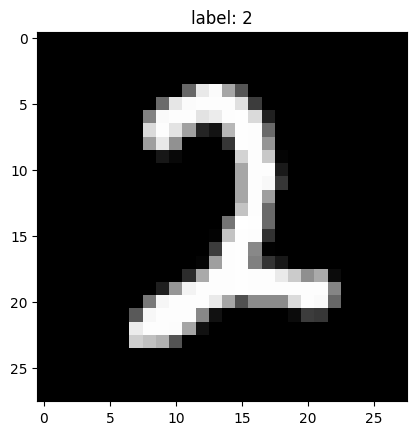

The sample has index: 2044.
Its label is 2, but the model predicted it to be a 7.


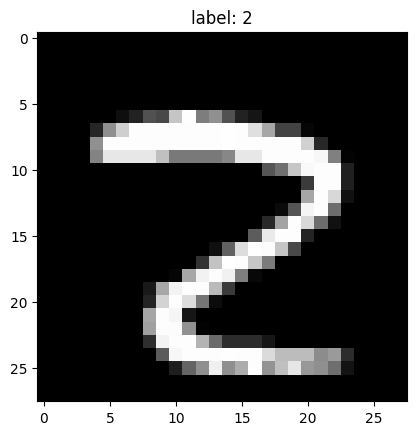

In [35]:
amount_of_samples = 5
worst_indices = torch.topk(
    nn.CrossEntropyLoss(reduction="none")(y_pred, test_labels_encoded),
    amount_of_samples,
).indices

for worst_index in worst_indices:
    print(f"The sample has index: {worst_index}.")
    print(
        f"Its label is {test_labels[worst_index]}, but the model predicted it to be a {torch.argmax(y_pred[worst_index])}."
    )

    image, label = test_input[worst_index], test_labels[worst_index]
    plt.imshow(image.reshape(28, 28).detach().cpu(), cmap='grey')
    plt.title(f"label: {label.item()}")
    plt.show()